# Customer Churn
---

## Introduction 
__Introduction to the topic__ 

In this project, I explore customer churn. The main goal is to understand why some customers leave the company while others stay. By analyzing customer data. I hope to find the main factors that affect customer churn and identify useful patterns.

## Problem Statement

The company is facing a high customer churn rate, where 55.52% of customers have left and only 44.48% have stayed.


## Objectives:
__Questions that will guide the analysis to solve the problem__

1. Who are the customers that leave the most? Which specific age groups and genders have the highest churn rates?

2. What are the main reasons causing these specific groups of customers to leave?

3. Do loyal customers spend more money and use the service more than churning customers?

4. Does calling customer support many times or having a long time since the last interaction mean the customer is about to leave?

5. Are payment delays a strong sign that a customer will cancel their subscription?

6. Does the type of contract like monthly or yearly make a difference in customer loyalty?

## Exploratory Data Analysis (EDA):

### Data Info:
__Getting the data and exploring it (includes descriptive statistics)__

In [148]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [149]:
train_df = pd.read_csv('customer_churn_dataset-training-master.csv')
test_df = pd.read_csv('customer_churn_dataset-testing-master.csv')


df = pd.concat([train_df, test_df] , ignore_index=True)

print(f"Number of rows after merging:")
print(df.head())

Number of rows after merging:
   CustomerID   Age  Gender  Tenure  Usage Frequency  Support Calls  \
0         2.0  30.0  Female    39.0             14.0            5.0   
1         3.0  65.0  Female    49.0              1.0           10.0   
2         4.0  55.0  Female    14.0              4.0            6.0   
3         5.0  58.0    Male    38.0             21.0            7.0   
4         6.0  23.0    Male    32.0             20.0            5.0   

   Payment Delay Subscription Type Contract Length  Total Spend  \
0           18.0          Standard          Annual        932.0   
1            8.0             Basic         Monthly        557.0   
2           18.0             Basic       Quarterly        185.0   
3            7.0          Standard         Monthly        396.0   
4            8.0             Basic         Monthly        617.0   

   Last Interaction  Churn  
0              17.0    1.0  
1               6.0    1.0  
2               3.0    1.0  
3              29.0    1

In [150]:
df.info() # Check data structure

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 505207 entries, 0 to 505206
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         505206 non-null  float64
 1   Age                505206 non-null  float64
 2   Gender             505206 non-null  object 
 3   Tenure             505206 non-null  float64
 4   Usage Frequency    505206 non-null  float64
 5   Support Calls      505206 non-null  float64
 6   Payment Delay      505206 non-null  float64
 7   Subscription Type  505206 non-null  object 
 8   Contract Length    505206 non-null  object 
 9   Total Spend        505206 non-null  float64
 10  Last Interaction   505206 non-null  float64
 11  Churn              505206 non-null  float64
dtypes: float64(9), object(3)
memory usage: 46.3+ MB


In [151]:
df.describe() # Summary statistics for columns

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,505206.000000,505206.000000,505206.000000,505206.000000,505206.000000,505206.000000,505206.000000,505206.000000,505206.000000
mean,200779.451782,39.704172,31.350435,15.714825,3.833317,13.496843,620.072766,14.610581,0.555203
std,137241.343095,12.670577,17.237482,8.619323,3.133603,8.451187,245.319256,8.608286,0.496944
min,1.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,63827.250000,29.000000,16.000000,8.000000,1.000000,6.000000,446.000000,7.000000,0.000000
50%,193039.500000,40.000000,32.000000,16.000000,3.000000,13.000000,648.900000,14.000000,1.000000
75%,321645.750000,49.000000,46.000000,23.000000,6.000000,20.000000,824.000000,22.000000,1.000000
max,449999.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


In [152]:
churn_conuts = df['Churn'].value_counts()
print(churn_conuts)
churn_percentages = df['Churn'].value_counts(normalize=True)*100
print(churn_percentages)

Churn
1.0    280492
0.0    224714
Name: count, dtype: int64
Churn
1.0    55.520322
0.0    44.479678
Name: proportion, dtype: float64


In [153]:
df.groupby('Gender')['Churn'].mean() * 100 
# Female customers have a much higher churn rate (64.89%) compared to male customers (47.99%).

Gender
Female    64.894435
Male      47.997131
Name: Churn, dtype: float64

In [154]:
df.groupby('Churn')['Age'].describe()
# The average age of customers who left (41.87 years old) is slightly higher than those who stayed (36.99 years old).

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
0.0,224714.0,36.997201,10.172578,18.0,29.0,38.0,45.0,65.0
1.0,280492.0,41.872841,13.988755,18.0,30.0,42.0,54.0,65.0


In [155]:
df.groupby('Churn')['Support Calls'].mean()
# Customers who churned have a much higher average of support calls (5.28 calls) compared to retained customers (2.02 calls).

Churn
0.0    2.025824
1.0    5.281377
Name: Support Calls, dtype: float64

### Data Handling: 
__Cleaning, transforming, and combining data__

In [156]:
df.isnull().sum() # Checking the missing values

CustomerID           1
Age                  1
Gender               1
Tenure               1
Usage Frequency      1
Support Calls        1
Payment Delay        1
Subscription Type    1
Contract Length      1
Total Spend          1
Last Interaction     1
Churn                1
dtype: int64

In [157]:
df.dropna(inplace=True) # drop the missimg values

In [158]:
percentage = (df.isnull().sum() / len(df)) * 100
percentage # Calculate percentage of missing values per column

CustomerID           0.0
Age                  0.0
Gender               0.0
Tenure               0.0
Usage Frequency      0.0
Support Calls        0.0
Payment Delay        0.0
Subscription Type    0.0
Contract Length      0.0
Total Spend          0.0
Last Interaction     0.0
Churn                0.0
dtype: float64

In [159]:
df.duplicated().sum() # Checking for duplicate rows , no have duplicate rows

np.int64(0)

In [160]:
df.shape # Checking the shape of the data

(505206, 12)

In [161]:
df.columns

Index(['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency',
       'Support Calls', 'Payment Delay', 'Subscription Type',
       'Contract Length', 'Total Spend', 'Last Interaction', 'Churn'],
      dtype='object')

In [162]:
df.drop(columns=['CustomerID']) 
# Drop ID because it is useless for prediction

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
505202,45.0,Female,33.0,12.0,6.0,21.0,Basic,Quarterly,947.0,14.0,1.0
505203,37.0,Male,6.0,1.0,5.0,22.0,Standard,Annual,923.0,9.0,1.0
505204,25.0,Male,39.0,14.0,8.0,30.0,Premium,Monthly,327.0,20.0,1.0
505205,50.0,Female,18.0,19.0,7.0,22.0,Standard,Monthly,540.0,13.0,1.0


In [163]:
df.describe()
# Show statistical summary and check data logic

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,505206.000000,505206.000000,505206.000000,505206.000000,505206.000000,505206.000000,505206.000000,505206.000000,505206.000000
mean,200779.451782,39.704172,31.350435,15.714825,3.833317,13.496843,620.072766,14.610581,0.555203
std,137241.343095,12.670577,17.237482,8.619323,3.133603,8.451187,245.319256,8.608286,0.496944
min,1.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,63827.250000,29.000000,16.000000,8.000000,1.000000,6.000000,446.000000,7.000000,0.000000
50%,193039.500000,40.000000,32.000000,16.000000,3.000000,13.000000,648.900000,14.000000,1.000000
75%,321645.750000,49.000000,46.000000,23.000000,6.000000,20.000000,824.000000,22.000000,1.000000
max,449999.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


### Analysis: 
__Answering the objectives through data analysis__



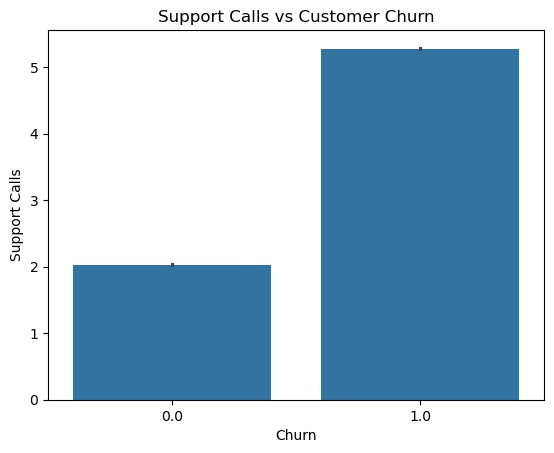

In [165]:
sns.barplot(x='Churn', y='Support Calls', data=df)
plt.title('Support Calls vs Customer Churn')
plt.show()

Customers who left averaged over 5 support calls, while those who stayed averaged only 2. This shows that more support calls mean higher customer dissatisfaction.

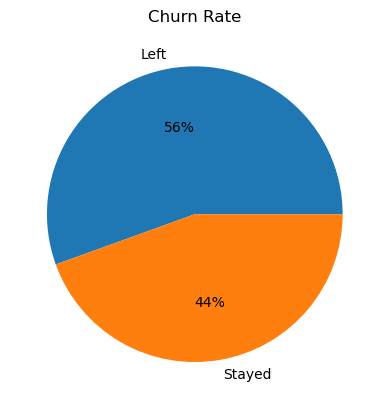

In [168]:
plt.pie(df['Churn'].value_counts(), labels=['Left', 'Stayed'], autopct='%1.0f%%')
plt.title('Churn Rate')
plt.show()

56% left 44% stayed. High churn problem.

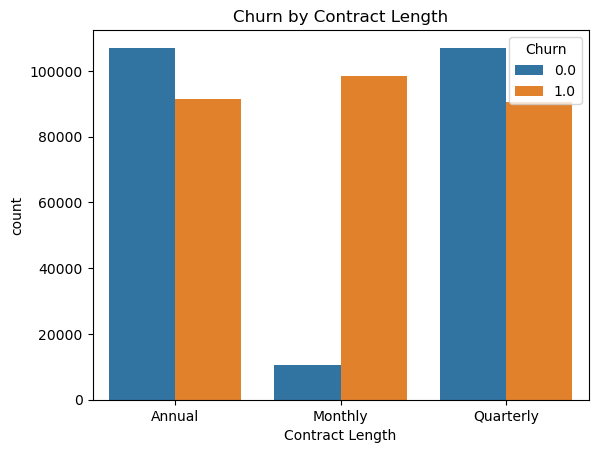

In [170]:
sns.countplot(x='Contract Length', hue='Churn', data=df)
plt.title('Churn by Contract Length')
plt.show()

Monthly Contracts: Have the highest churn with almost everyone leaving (1.0).

Annual  Quarterly: Have more customers staying (0.0) than leaving.

Conclusion: Monthly contracts are the main driver for customer churn.

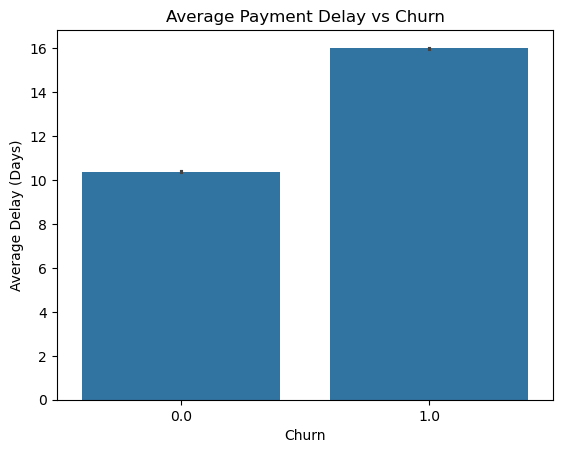

In [174]:
sns.barplot(x='Churn', y='Payment Delay', data=df)
plt.title('Average Payment Delay vs Churn')
plt.ylabel('Average Delay (Days)')
plt.show()

Customers who left (1.0): High average payment delay of 16 days.

Customers who stayed (0.0): Lower average payment delay of 10 days.

Longer payment delays are strongly linked to higher customer churn.

---

## Summary
__Summarizing the key insights from the analysis__

1. Age: Older customers (around 45) leave the most, while younger ones (around 35) stay.

2. Main Reasons: Short-term contracts, too many support calls, and late payments.

3. Usage: Loyal customers spend more and use the service regularly, while churning customers stop using it before they leave.

4. Support Calls: Reaching more than 5 support calls is a huge warning sign that the customer is quitting.

5. Late Payments: Churned customers delay their bills by 16 days on average, compared to only 10 days for loyal ones.

6. Contracts: Monthly contracts have the worst churn rates, while annual and quarterly contracts keep customers long-term.



## Recommendations/Conclusion

1. Push Long-Term Contracts: Give discounts to move monthly users to annual or quarterly plans, because monthly contracts have the worst churn rates.

2. Fix Issues Fast:Alert the support team immediately when a customer hits 5 support calls, so they can solve the problem before the user gets frustrated and leaves.

3. Early Bill Reminders: Send automatic payment reminders around day 10 to stop users from hitting the critical 16-day delay mark.

4. Focus on Older Users: Create special loyalty offers or better support for older customers (around 45) since the data shows they quit the most.

5. Track Usage Drops: Monitor when a customer suddenly stops using the service and send them a special offer to win them back before they cancel.